In [2]:
from numpy.random import lognormal, uniform
from numpy import exp, linspace ,log, max, mean ,  sqrt
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Monte Carlo Computational Finance context

## Monte Carlo : Big Idea

1. Monte Carlo simulation can be used to compute integrals and compute expected values

1. In the computational finance context Monte carlo simulations is used to price various assets by estimating the expected value

1. First a stochastic asset paths are generated under the risk neutral or any other measure 

1. Second for each random paths generated we can compute the payoffs at time T

1. The value of the derivative can be approximated by computing the the expected discounted value under each path

1. Monte Carlo simulation is known to work quite well with path dependent options

1. from a Mathematical point of view MC methods are based on the *central limit theorem* and the *law of large numbers*

1. Since the result of an experiement is a random number the structure of the error has a probabilistic distribution


## Monte Carlo : Expectation and Standard error

1. Consider we want to compute by monte Carlo simulation $ \mathbb{E} \left[X \right] = \mu_X $

1. What we need is to generate $N$ samples $X_1, X_2, ...,X_N$

1. Then naturally we have $ \mathbb{E} \left[X \right] \approx  \bar{X_i} := \text{mean}(X_i) $

1. The sample standard  error is defined as $\sigma_{\epsilon} = \dfrac{\text{vol}(X_i)}{\sqrt N}$

1. From the central limit theoreom we know that $\bar{X}_i \sim N( \mu_X, \sigma_{\epsilon} )$

1. Given that we know the distribution of the sample mean we can 
    * define confidence intervals
    * compute the number of sample needed for a given level of error


 

## Monte Carlo : Integration

### Naive Approach

1. Suppose we have an X, Y plane, where we draw random numbers ( dots in the gragh). The MC integral of a function is simply the total area times the %of dots that fall inder the curve $g(x)$ <br>  
<kbd>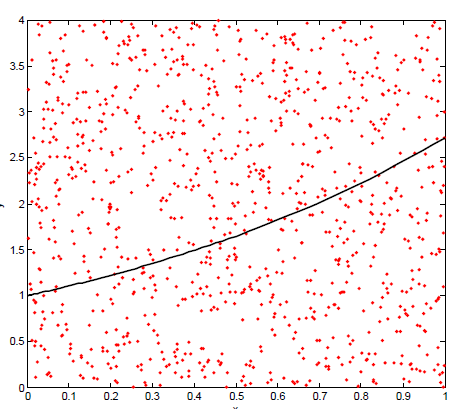 </kbd><br> <br>
    
1. In finance typycally this is not the method used but can be helpful if we have a very complicated multi dimentional function

**Code example**
1. The function below estimates $\int_a^b g(x)dx$ by Monte carlo simulation
1. Note that $c$ and $d$ must be chosen so that the rectagle ABCD always contains the area under the Curve g(x) 

Integral from Monte Carlo Naive apporach is 6.468


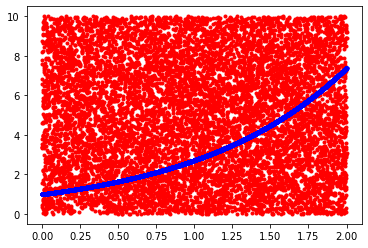

In [10]:
def ComputeIntegral_naive_approach(N,a,b,c,d,g):  
    # first pick N dots in in the retangle base [a, b] height [c,d] 
    x_i = uniform(a,b,N)
    y_i = uniform(c,d,N)
    g_i = g(x_i)
    
    # compute the % of points below g(x)
    p_i = g_i > y_i
    p = np.sum(p_i) / NoOfSamples
    
    # integral is the portion of the area under the curve
    integral = p * (b-a)*(d-c) 
    
    plt.figure(1)
    plt.plot(x_i,y_i,'.r')
    plt.plot(x_i,g_i,'.b')
    return integral


NoOfSamples = 10_000

a = 0.0
b = 2.0
c = 0.0
d = 10.0 

g = lambda x: np.exp(x) 

output = ComputeIntegral_naive_approach(NoOfSamples,a,b,c,d,g)
print('Integral from Monte Carlo Naive apporach is {0}'.format(output))


### Expectation approach (Brandimarte section 4.2)

1. The definite integral of a function is deterministic there is nothing random about it

1. Nevertheless we can cast the issue into a stocastic framework

1. Key is to view the integral as the expected value of 

1. Consider the integral $I = \int_0^1g(x)dx$

1. we can see this integral as $I = \mathbb{E}\left[ g(X) \right]$ where $X$ ~ $U(0,1)$

1. Hence we can estimate the integral by generating $N$ sample $X_i$ and compute $I = \text{mean}(g_i) \times (1-0)$ 
    
1. In general if we want to compute $ I = \int_{\mathcal{A}} g(\mathbf{x})d\mathbf{x}$ we need to 
    * Choose N random points in $\mathcal{A}$
    * Estimate the integral as $I \approx \text{vol}(\mathcal{A})\times \text{mean}(g_i)$
    * Note that the error is reduced by a factor of $\sqrt N$
<br>  <br>    

1. In finance typycally this is not the method used but can be helpful if we have a very complicated multi dimentional function

**Code example**

In [3]:
def ComputeIntegral_expectation_approach(N,a,b,g): 
    x_i = uniform(a,b,N)   
    g_i = g(x_i)
    I = (b-a) * np.mean(g_i)
    return I

output2 = ComputeIntegral_expectation_approach(NoOfSamples,a,b,g)
print('Integral from Monte Carlo Expcteation approach is {0}'.format(output2))


Integral from Monte Carlo Expctation approach is 6.419012268018854


## Monte Carlo : Convergence issues

### impact function smoothness and convergence

1. Monte Carlo convergence does depends on the smoothness of the pay-off function

1. For excample consider:
    * $f(x) = \mathbb{1}_{x \geq 0}$
    * $g(x)  = F_{\mathscr{N}(0,1)}(x)$
    
1. Analyticaly we can show that $ \mathbb{E} \left[ f(W_1) \right] = \mathbb{E} \left[ g(W_1) \right] =\dfrac{1}{2}  $

1. However by monte carlo simulation we may see differences in convergence

1. lets define the estimated mean by MC simulation with paths as  :  $$\bar\mu_f = \dfrac{1}{M} \sum_{i=1}^{M} f_i $$  $$\bar\mu_g = \dfrac{1}{M} \sum_{i=1}^{M} g_i $$

1. And the MC error as : $$\epsilon_f = \bar\mu_f - 0.5 $$  $$\epsilon_g = \bar\mu_g - 0.5 $$

1. below we plot the error for various number of paths

1. We can see that the smooth function converges faster 

1. This is because $\text{vol}(f_i) > \text{vol}(g_i)$

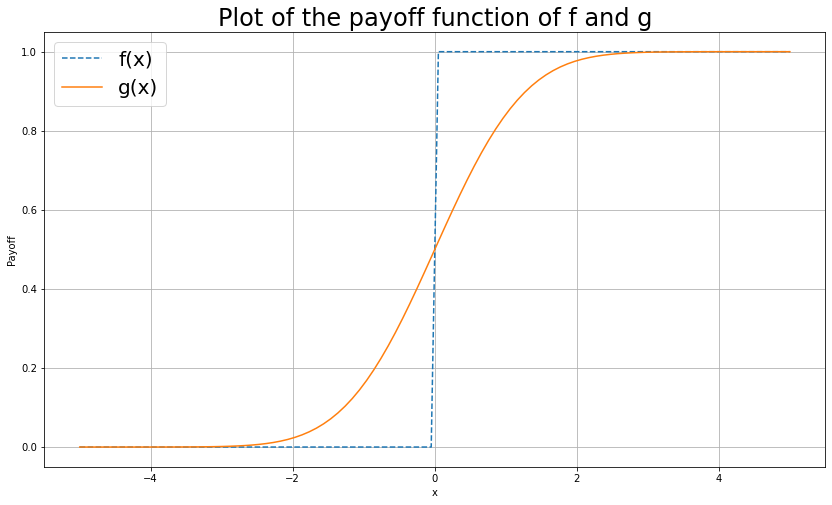

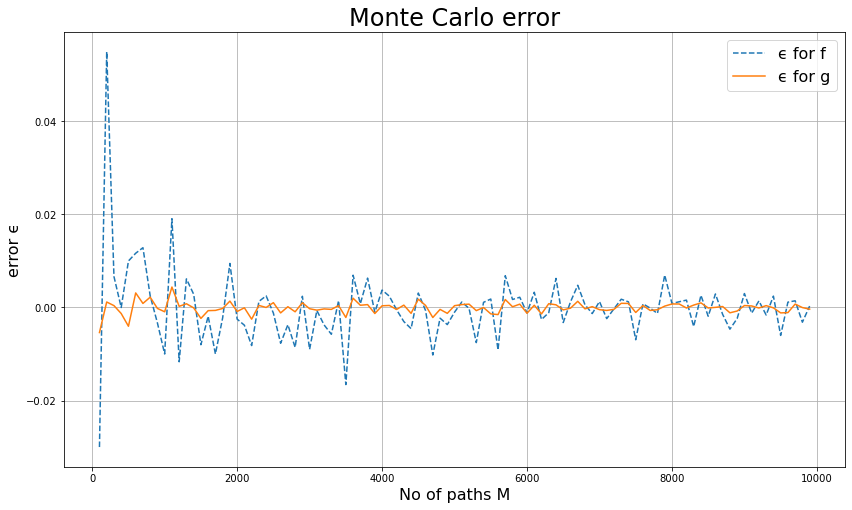

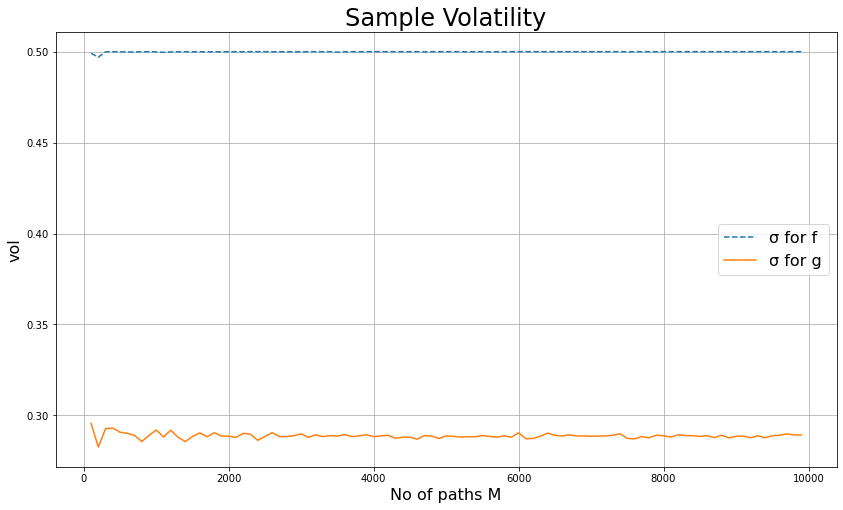

In [4]:
M_list = range(100,10000,100)

# Define two payoff functions
f = lambda x: (x > 0.0)
g = lambda x: norm.cdf(x)

# Plot the f and g functions
x = np.linspace(-5.0,5.0,100)
plt.figure(1, figsize = (14,8))
plt.plot(x,f(x), '--')
plt.plot(x,g(x))
plt.grid()
plt.xlabel('x')#, fontsize = 16)
plt.ylabel('Payoff')#, fontsize = 16)
plt.title('Plot of the payoff function of f and g', fontsize = 24 )
plt.legend(['f(x)','g(x)'], fontsize = 20);

# Store the errors 
ϵ_f = np.zeros([len(M_list),1])
ϵ_g = np.zeros([len(M_list),1])

# Store the sample vols 
vol_f = np.zeros([len(M_list),1])
vol_g = np.zeros([len(M_list),1])

for i, M in enumerate(M_list):
    W1 = np.random.normal(0.0,1.0,[M,1])
    if M > 1:  W1 = (W1 - np.mean(W1)) / np.std(W1)
    μ_f = np.mean(f(W1))
    μ_g = np.mean(g(W1))
    
    ϵ_f[i] = μ_f - 0.5
    ϵ_g[i] = μ_g - 0.5
    
    vol_f[i] = np.std(f(W1))
    vol_g[i] = np.std(g(W1))

# Plot convergence results
plt.figure(2, figsize = (14,8))
plt.plot(M_list,ϵ_f,  '--')
plt.plot(M_list,ϵ_g)
plt.grid()
plt.xlabel('No of paths M', fontsize = 16)
plt.ylabel('error ϵ', fontsize = 16)
plt.legend(['ϵ for f ','ϵ for g'], fontsize = 16);
plt.title('Monte Carlo error', fontsize = 24 );

# Plot convergence results
plt.figure(3, figsize = (14,8))
plt.plot(M_list,vol_f,  '--')
plt.plot(M_list,vol_g)
plt.grid()
plt.xlabel('No of paths M', fontsize = 16)
plt.ylabel('vol', fontsize = 16)
plt.legend(['σ for f ','σ for g'], fontsize = 16);
plt.title('Sample Volatility', fontsize = 24 );





### Strong vs Weak convergence 

1. Consider a monte carlo simulation where we have $M$ paths and $N$ time step for a random variable $X(t)$

1. The size of the time steps is defined by $\Delta_t = \dfrac{T}{N}$

1. Let's denote $X_N$ the approximation of $X(T)$ at the final time step

1. Let $g(.)$ be a sufficiently smooth function and for notation purpose 
    - $g_N := g(X_N)$ 
    - $g_T := g(X_T)$
<br><br>
1. <font color='blue'>**Strong Convergence:** </font> we say the approximation $X_N$ converge in a strong sense with order $\alpha$ when we have <br><br>
$$\boxed{\epsilon^{s}(\Delta t) = \mathbb{E}\left[ | X_N - X(T) | \right] =\mathscr{O}\left( \Delta_t^{\alpha} \right)}$$

1. <font color='blue'>**Weak Convergence:** </font> we say the approximation $X_N$ converge in a weak sense with order $\beta$ when we have <br><br>
$$\boxed{\epsilon^{w}(\Delta t) = | \mathbb{E}\left[g_N \right]  -   \mathbb{E}\left[ g_T\right] |  = \mathscr{O}\left( \Delta_t^{\beta} \right)  } $$

1. For example consider we run a monte carlo simulation with 3 path and the results are tabulated in the table below <br>


1. We can see that we do not have strong convergence given the error on each path are large 
    - On path 1 we have:  $| X_N - X(T) | = |1- 0.5 | = 0.5$ 
    - On path 2 we have:  $| X_N - X(T) | = |2- 5.0 | = 3.0$ 
    - On path 3 we have:  $| X_N - X(T) | = |3- 0.5 | = 2.5$ 
    - hence we have $\mathbb{E}\left[  | X_N - X(T) | \right]$ = 2 large error
    <br><br>
1. However this converges in the weak sense for $g(x)=x$ because :
    - $\mathbb{E}\left[  g_N\right] = \frac{1+2+3}{3} = 2$
    - $\mathbb{E}\left[  g_T\right] = \frac{0.5 +5+0.5}{3} = 2$
    - hence we have $|  \mathbb{E}\left[  g_N\right]  - \mathbb{E}\left[  g_T \right]   | $ = 0
<br><br>

1. Intuitively strong converge mean we converge on each path/scenarios whereas weak converge mean convergences of expectation

1. When we have to deal with exotive derivatives whose payoff is path dependent then having strong convergence may be required



## Discretization schemes : Euler vs Milstein

1. Consider a stochastic differencial equation <br><br>
$$dX_t = \Theta(t,X_t)dt + \Psi(t, X_t)dW_t$$

1. Its solution is given by <br><br>
$$X(T) = x_0 + \int_{t_0}^T\Theta(t,X_t)dt  + \int_{t_0}^T\Psi(t, X_t)dW_t$$

1. Generally this solution needs to be computed numerically. Only for a small subset of processes we can find a close form solution

1. To solve numerically we set set a grid of point on $\left[ 0, T \right]$ then we have <br><br>
$$x_{i+1} = x_i +  \int_{t_i}^{t{_{i+1}}}\Theta(t,X_t)dt  + \int_{t_i}^{t{_{i+1}}}\Psi(t, X_t)dW_t$$

1. <font color='blue'>**Stochastic Euler Schemes:** </font> 
    * Basic numerical integration method for computing stochastic integrals like the one described above
    * It has a strong convergence of order $\frac{1}{2}$ and weak convergence of order 1
    * The integrand is approximated by the _left side boundary_ of the integration integral
$$
\begin{align}
x_{i+1} &= x_i +  \int_{t_i}^{t{_{i+1}}}\Theta(t,X_t)dt  + \int_{t_i}^{t{_{i+1}}}\Psi(t, X_t)dW_t \\
        &\approx x_i +  \int_{t_i}^{t{_{i+1}}}\Theta(t_i,x_i)dt  + \int_{t_i}^{t{_{i+1}}}\Psi(t_i,x_i)dW_t \\
        &\approx x_i + \Theta(t_i,x_i) \left(t_{i+1} - t_{i}\right) + \Psi(t_i,x_i)(W_{t_{i+1}} - W_{t_{i}}) \\
\end{align}
$$
Hence the discretization
$$\boxed{ x_{i+1} =    x_i + \Theta(t_i,x_i) dt + \Psi(t_i,x_i)dW_t }$$

1. <font color='blue'>**Stochastic Milstein Schemes:** </font> 
    * Is like the Euler scheme but involve the addition of the next order term in the **_Ito-Taylor_** expansion
    * It has a strong and weak convergence of order 1
    * The integrand is approximated by the _left side boundary_ of the integration integral
$$
\begin{align}
x_{i+1} &= x_i +  \int_{t_i}^{t{_{i+1}}}\Theta(t,X_t)dt  + \int_{t_i}^{t{_{i+1}}}\Psi(t, X_t)dW_t \\
        &\approx x_i +  \int_{t_i}^{t{_{i+1}}}\Theta(t_i,x_i)dt  + \int_{t_i}^{t{_{i+1}}}\Psi(t_i,x_i)dW_t +  \dfrac{1}{2}\Psi(t_i,x_i) \left[  (W_{t_{i+1}} - W_{t_{i}})^2 - \Delta_t\right] \Psi_x(t_i, x_i) \\
        &\approx x_i + \Theta(t_i,x_i) \left(t_{i+1} - t_{i}\right) + \Psi(t_i,x_i)(W_{t_{i+1}} - W_{t_{i}}) + \dfrac{1}{2}\Psi(t_i,x_i) \left[  (W_{t_{i+1}} - W_{t_{i}})^2 - \Delta_t\right] \Psi_x(t_i, x_i) \\
\end{align}
$$
Hence the discretization
$$\boxed{ x_{i+1} =    x_i + \Theta(t_i,x_i) dt + \Psi(t_i,x_i)dW_t +\color{purple}{  \dfrac{1}{2}\Psi(t_i,x_i) \left[  dW_t^2 - dt\right] \Psi_x(t_i, x_i) }} 
$$





## Monte Carlo : Application

### path simulations Geometrical Brownian motion

1. The dynamics of the geometrical brownian motion can be written as 
$$dS_t = r S_t dt + \sigma S_t dW_t$$

1. The Euler discretization on the $i^{th}$ path at the $j^{th}$ time step is $$s_{i,j+1} \approx s_{i,j}  +  r s_{i,j}\Delta t +  \sigma s_{i,j} dW_{i,j+1}$$

1. The Milstein discretization on the $i^{th}$ path at the $j^{th}$ time step is $$s_{i,j+1} \approx s_{i,j}  +  r s_{i,j}\Delta t +  \sigma s_{i,j} dW_{i,j+1}  +\color{purple}{  \dfrac{1}{2}\sigma^{2}s_i \left( dW_{i,j+1}^2 - \Delta t \right)}$$ <br>

1. We can also show that the GBM has exact solution $$S(t_{i+1}) = S(t_i) \text{exp} \left( (r-\dfrac{1}{2}\sigma^2) \Delta t  +  \sigma dW_{i+1}\right)$$

1. We can compute the strong convergence error for different $\Delta t$ as <br>
$$\epsilon^{s}(\Delta t) = \dfrac{1}{M}\sum_{i=1}^{M} |  S_{i,N} - s_{i,N} |   $$

1. We can compute the weak convergence error for different $\Delta t$ as <br>
$$\epsilon^{w}(\Delta t) = \left| \dfrac{1}{M}\sum_{i=1}^{M}  S_{i,N} - \dfrac{1}{M}\sum_{i=1}^{M}   s_{i,N}  \right| $$

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

def GBM_paths(M,N,T,r,σ,So):
    # time grid
    t = np.zeros([N+1])   
    dt = T / float(N)
    
    Z = np.random.normal(0.0,1.0,[M,N])
    W = np.zeros([M, N+1])

    # Approximation by euler scheme array
    euler_S = np.zeros([M, N+1])
    euler_S[:,0] =So
    
    # Approximation by Milstein scheme array
    milstein_S = np.zeros([M, N+1])
    milstein_S[:,0] =So

    # Exact solution
    exact_S = np.zeros([M, N+1])
    exact_S[:,0] =So

    

    for j in range(0,N):

        # Making sure that samples from a normal have mean 0 and variance 1
        if M > 1: Z[:,j] = (Z[:,j] - np.mean(Z[:,j])) / np.std(Z[:,j])
        W[:,j+1] = W[:,j] + np.power(dt, 0.5)*Z[:,j]
        dW =  W[:,j+1] - W[:,j]

        euler_S[:,j+1] = euler_S[:,j] + r * euler_S[:,j]* dt + σ * euler_S[:,j] * dW
        milstein_S[:,j+1] = milstein_S[:,j] + r * milstein_S[:,j]* dt + σ * milstein_S[:,j] * dW + 1/2 * σ **2 * milstein_S[:,j] * ( dW**2 - dt)                                          
        exact_S[:,j+1] = exact_S[:,j] * np.exp((r - 0.5*σ**2) *dt + σ * dW)
        t[j+1] = t[j] +dt
        
    return { 't' : t, 'Euler Paths': euler_S, 'Milstein Paths' : milstein_S ,'Exact Paths' : exact_S}

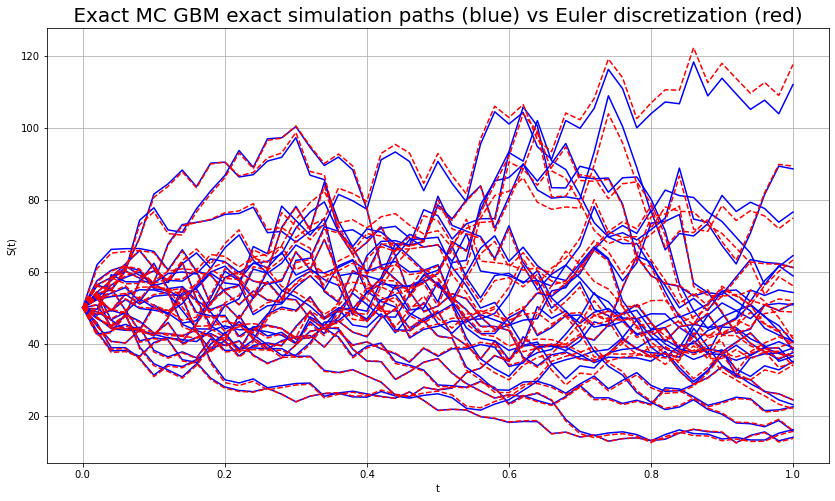

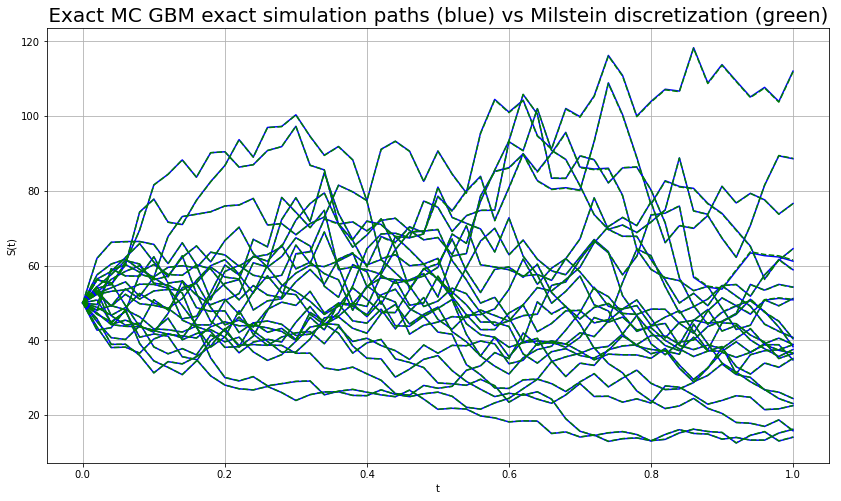

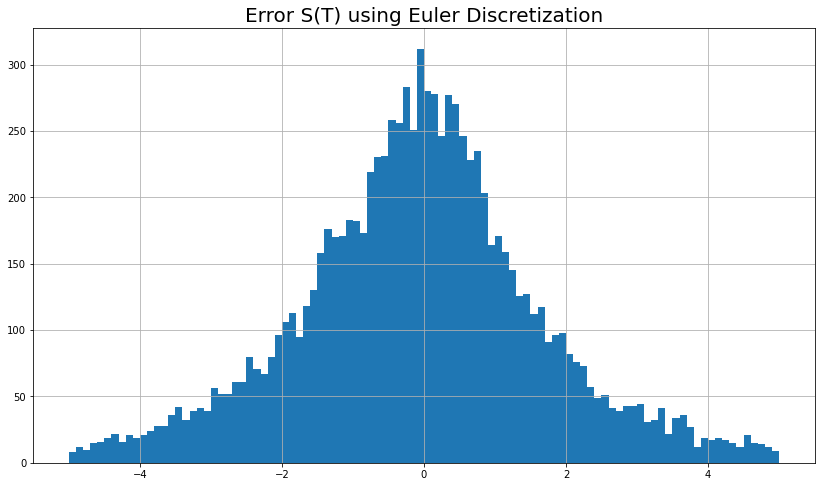

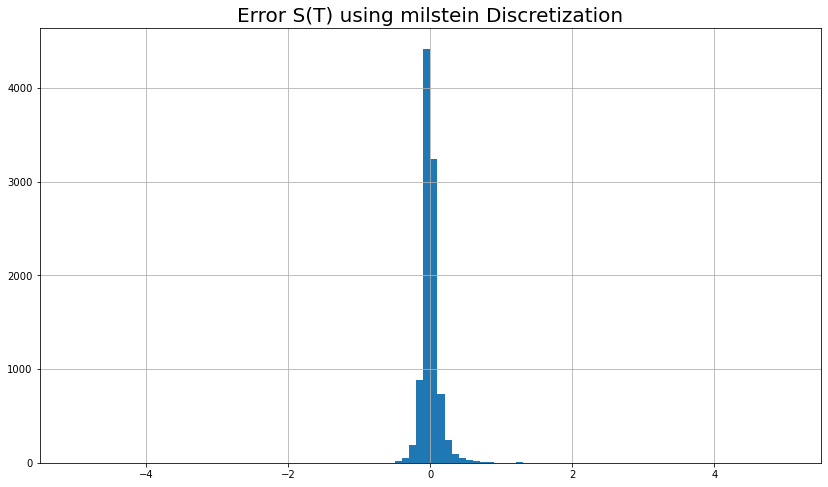

In [6]:
M = 10000
N = 50
T = 1
r = 0.06
σ = 0.6
So = 50

res = GBM_paths(M,N,T,r,σ,So)
t =  res['t']
exact_S =  res['Exact Paths']
euler_S =  res['Euler Paths']
milstein_S =  res['Milstein Paths']


euler_S_T = euler_S[:,-1]
milstein_S_T = milstein_S[:,-1]
exact_S_T = exact_S[:,-1]


plt.figure( figsize = (14,8))
plt.plot(t, np.transpose(exact_S[0:25,:]), color = 'blue', label = 'Exact Paths')   
plt.plot(t, np.transpose(euler_S[0:25,:]),color = 'red', linestyle = 'dashed', label = 'Euler Paths')   
plt.grid()
plt.xlabel("t")
plt.ylabel("S(t)")
# plt.legend(['Exact Paths','Euler Paths'])
plt.title(' Exact MC GBM exact simulation paths (blue) vs Euler discretization (red) ', fontsize=20 );

plt.figure( figsize = (14,8))
plt.plot(t, np.transpose(exact_S[0:25,:]), color = 'blue', label = 'Exact Paths')   
plt.plot(t, np.transpose(milstein_S[0:25,:]),color = 'green', linestyle = 'dashed', label = 'Milstein Paths')   
plt.grid()
plt.xlabel("t")
plt.ylabel("S(t)")
# plt.legend(['Exact Paths','Euler Paths'])
plt.title(' Exact MC GBM exact simulation paths (blue) vs Milstein discretization (green) ', fontsize=20 );


plt.figure(figsize = (14,8))
plt.hist( exact_S_T - euler_S_T, 100 ,range=(-5,5))
plt.grid()
plt.title('Error S(T) using Euler Discretization', fontsize=20 );


plt.figure(figsize = (14,8))
plt.hist(exact_S_T - milstein_S_T, 100, range=(-5,5))
plt.grid()
plt.title('Error S(T) using milstein Discretization', fontsize=20 );

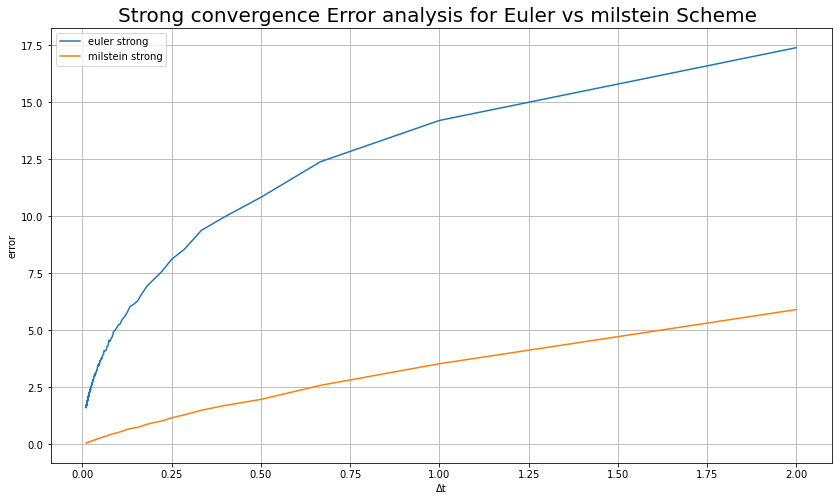

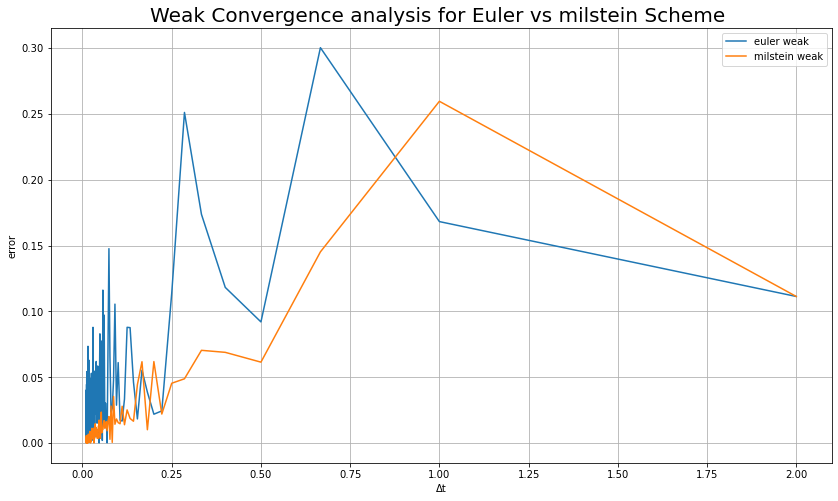

In [10]:
T = 2
# Weak and strong convergence
N_list = range(1,200,1)
M = 10_000
ϵ_weak_euler = np.zeros([len(N_list),1])
ϵ_strong_euler = np.zeros([len(N_list),1])
ϵ_weak_milstein = np.zeros([len(N_list),1])
ϵ_strong_milstein = np.zeros([len(N_list),1])


dt_list = np.zeros([len(N_list),1])
for i, N in enumerate(N_list):
    Paths = GBM_paths(M,N,T,r,σ,So)

    # Get the paths at T
    euler_S_T = Paths['Euler Paths'][:,-1]
    milstein_S_T = Paths['Milstein Paths'][:,-1]
    exact_S_T = Paths['Exact Paths'][:,-1]
    
    # weak euler and milstein
    ϵ_weak_euler[i] = np.abs(np.mean(euler_S_T)-np.mean(exact_S_T))
    ϵ_weak_milstein[i] = np.abs(np.mean(milstein_S_T)-np.mean(exact_S_T))
    
    # stong euler and milstein
    ϵ_strong_euler[i] = np.mean(np.abs(euler_S_T-exact_S_T))
    ϵ_strong_milstein[i] = np.mean(np.abs(milstein_S_T-exact_S_T))
    
    dt_list[i] = T/N

    


    
    
    
plt.figure(figsize = (14,8))
plt.plot(dt_list,ϵ_strong_euler, label = 'euler strong')
plt.plot(dt_list,ϵ_strong_milstein, label = 'milstein strong')
plt.grid()
plt.legend()
plt.xlabel("Δt")
plt.ylabel("error")
plt.title('Strong convergence Error analysis for Euler vs milstein Scheme ', fontsize=20 );


plt.figure(figsize = (14,8))
plt.plot(dt_list,ϵ_weak_euler, label = 'euler weak')
plt.plot(dt_list,ϵ_weak_milstein, label = 'milstein weak')
plt.grid()
plt.legend()
plt.xlabel("Δt")
plt.ylabel("error")
plt.title('Weak Convergence analysis for Euler vs milstein Scheme ', fontsize=20 );






### European option pricing

1. Application is for pricing of European style derivatives

1. Consider the Ito process  $$dS_t = \mu(t,S_t)dt + \sigma(t, S_t)dW^{\mathbb{Q}}_t$$

1. Consider the derivative security $V(t, S_t)$ with final payoff function $$V(T, S_T) = H(S_T)$$

1. We can value to option by using the fundamental theorem of asset pricing $$V(t,S_t) = e^{r(T-t_0)}\mathbb{E^Q} \left[ H(S_T) \right] $$

1. When the pdf is not available in closed form monte carlo simulation can be used

#### Digital and european option pricing my MC

The code below has :

* GBM path generation using 
    * Euler discretization
    * Milstein discretization
    
* Black scholes formula for 
    * Digital European put and call option
    * Regular European put and call option

* Pricing by MC simulation of 
    * Digital option 
    * regular options
    

In [8]:
#%%
"""
Created on Jan 20 2019
Convergence of option prices for Euler and Milsten schemes
@author: Lech A. Grzelak
"""
import numpy as np
import scipy.stats as st
import enum 

# set i= imaginary number
i   = np.complex(0.0,1.0)

# This class defines puts and calls
class OptionType(enum.Enum):
    CALL = 1.0
    PUT = -1.0
    
# Black-Scholes Call option price
def BS_Call_Option_Price(CP,S_0,K,sigma,tau,r):
    
    K = np.array(K).reshape([len(K),1])
    d1    = (np.log(S_0 / K) + (r + 0.5 * np.power(sigma,2.0)) 
    * tau) / float(sigma * np.sqrt(tau))
    d2    = d1 - sigma * np.sqrt(tau)
    if CP == OptionType.CALL:
        value = st.norm.cdf(d1) * S_0 - st.norm.cdf(d2) * K * np.exp(-r * tau)
    elif CP == OptionType.PUT:
        value = st.norm.cdf(-d2) * K * np.exp(-r * tau) - st.norm.cdf(-d1)*S_0
    return value

def GeneratePathsGBMEuler(NoOfPaths,NoOfSteps,T,r,sigma,S_0):    
    Z = np.random.normal(0.0,1.0,[NoOfPaths,NoOfSteps])
    W = np.zeros([NoOfPaths, NoOfSteps+1])
   
    # Euler Approximation
    S1 = np.zeros([NoOfPaths, NoOfSteps+1])
    S1[:,0] =S_0
    
    time = np.zeros([NoOfSteps+1])
        
    dt = T / float(NoOfSteps)
    for i in range(0,NoOfSteps):
        # making sure that samples from normal have mean 0 and variance 1
        if NoOfPaths > 1:
            Z[:,i] = (Z[:,i] - np.mean(Z[:,i])) / np.std(Z[:,i])
        W[:,i+1] = W[:,i] + np.power(dt, 0.5)*Z[:,i]
        
        S1[:,i+1] = S1[:,i] + r * S1[:,i]* dt + sigma * S1[:,i] * (W[:,i+1] - W[:,i])
        time[i+1] = time[i] +dt
        
    # Retun S1 and S2
    paths = {"time":time,"S":S1}
    return paths


#Black-Scholes for cash or nothing option
def BS_Cash_Or_Nothing_Price(CP,S_0,K,sigma,tau,r):
    K = np.array(K).reshape([len(K),1])
    d1    = (np.log(S_0 / K) + (r + 0.5 * np.power(sigma,2.0)) 
    * tau) / float(sigma * np.sqrt(tau))
    d2    = d1 - sigma * np.sqrt(tau)
    if CP == OptionType.CALL:
        value = K * np.exp(-r * tau) * st.norm.cdf(d2)
    if CP == OptionType.PUT:
        value = K * np.exp(-r * tau) *(1.0 - st.norm.cdf(d2))
    return value

def GeneratePathsGBMMilstein(NoOfPaths,NoOfSteps,T,r,sigma,S_0):    
    Z = np.random.normal(0.0,1.0,[NoOfPaths,NoOfSteps])
    W = np.zeros([NoOfPaths, NoOfSteps+1])
   
    # Milstein Approximation
    S1 = np.zeros([NoOfPaths, NoOfSteps+1])
    S1[:,0] =S_0
       
    time = np.zeros([NoOfSteps+1])
        
    dt = T / float(NoOfSteps)
    for i in range(0,NoOfSteps):
        # making sure that samples from normal have mean 0 and variance 1
        if NoOfPaths > 1:
            Z[:,i] = (Z[:,i] - np.mean(Z[:,i])) / np.std(Z[:,i])
        W[:,i+1] = W[:,i] + np.power(dt, 0.5)*Z[:,i]
        
        S1[:,i+1] = S1[:,i] + r * S1[:,i]* dt + sigma * S1[:,i] * (W[:,i+1] - W[:,i]) \
                    + 0.5 * sigma **2.0 * S1[:,i] * (np.power((W[:,i+1] - W[:,i]),2) - dt)
        time[i+1] = time[i] +dt
        
    # Retun S1 and S2
    paths = {"time":time,"S":S1}
    return paths

def EUOptionPriceFromMCPaths(CP,S,K,T,r):
    # S is a vector of Monte Carlo samples at T
    if CP == OptionType.CALL:
        return np.exp(-r*T)*np.mean(np.maximum(S-K,0.0))
    elif CP == OptionType.PUT:
        return np.exp(-r*T)*np.mean(np.maximum(K-S,0.0))

def CashofNothingPriceFromMCPaths(CP,S,K,T,r):
    # S is a vector of Monte Carlo samples at T
    if CP == OptionType.CALL:
        return np.exp(-r*T)*K*np.mean((S>K))
    elif CP == OptionType.PUT:
        return np.exp(-r*T)*K*np.mean((S<=K))

def mainCalculation():
    CP= OptionType.CALL
    T = 1
    r = 0.06
    sigma = 0.3
    S_0 = 5
    K = [S_0]
    NoOfSteps =1000
    
    # Simulated paths
    NoOfPathsV = [100,1000,5000,10000]
    
    # Call price
    exactPrice = BS_Call_Option_Price(CP,S_0,K,sigma,T,r)[0]
    print("EUROPEAN OPTION PRICING")
    print("Exact option price = {0}".format(exactPrice))
    for NoOfPathsTemp in NoOfPathsV:
        np.random.seed(1)
        PathsEuler    = GeneratePathsGBMEuler(NoOfPathsTemp,NoOfSteps,T,r,sigma,S_0)
        np.random.seed(1)
        PathsMilstein = GeneratePathsGBMMilstein(NoOfPathsTemp,NoOfSteps,T,r,sigma,S_0)
        S_Euler = PathsEuler["S"]
        S_Milstein = PathsMilstein["S"]
        priceEuler = EUOptionPriceFromMCPaths(CP,S_Euler[:,-1],K,T,r)
        priceMilstein = EUOptionPriceFromMCPaths(CP,S_Milstein[:,-1],K,T,r)
        print("For N = {0} Euler scheme yields option price = {1} and Milstein {2}"\
              .format(NoOfPathsTemp,priceEuler,priceMilstein))
        print("For N = {0} Euler error = {1} and Milstein  error {2}"\
              .format(NoOfPathsTemp,priceEuler-exactPrice,priceMilstein-exactPrice))
    
    # Cash or nothing price
    print("CASH OR NOTHING PRICING")
    exactPrice = BS_Cash_Or_Nothing_Price(CP,S_0,K,sigma,T,r)
    print("Exact option price = {0}".format(exactPrice))
    for NoOfPathsTemp in NoOfPathsV:
        np.random.seed(1)
        PathsEuler    = GeneratePathsGBMEuler(NoOfPathsTemp,NoOfSteps,T,r,sigma,S_0)
        np.random.seed(1)
        PathsMilstein = GeneratePathsGBMMilstein(NoOfPathsTemp,NoOfSteps,T,r,sigma,S_0)
        S_Euler = PathsEuler["S"]
        S_Milstein = PathsMilstein["S"]
        priceEuler = CashofNothingPriceFromMCPaths(CP,S_Euler[:,-1],K[0],T,r)
        priceMilstein = CashofNothingPriceFromMCPaths(CP,S_Milstein[:,-1],K[0],T,r)
        print("For N = {0} Euler scheme yields option price = {1} and Milstein {2}"\
              .format(NoOfPathsTemp,priceEuler,priceMilstein))
        print("For N = {0} Euler error = {1} and Milstein  error {2}"\
              .format(NoOfPathsTemp,priceEuler-exactPrice,priceMilstein-exactPrice))
mainCalculation()

C:\Users\wb548956\AppData\Local\Temp/ipykernel_32608/3313265056.py:12: DeprecationWarning: `np.complex` is a deprecated alias for the builtin `complex`. To silence this warning, use `complex` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.complex128` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  i   = np.complex(0.0,1.0)


EUROPEAN OPTION PRICING
Exact option price = [0.73585362]
For N = 100 Euler scheme yields option price = 0.7285547612550968 and Milstein 0.728444051871542
For N = 100 Euler error = [-0.00729886] and Milstein  error [-0.00740957]
For N = 1000 Euler scheme yields option price = 0.7200580888738554 and Milstein 0.7202098357606097
For N = 1000 Euler error = [-0.01579553] and Milstein  error [-0.01564379]
For N = 5000 Euler scheme yields option price = 0.7481360160804368 and Milstein 0.7481404588408821
For N = 5000 Euler error = [0.0122824] and Milstein  error [0.01228684]
For N = 10000 Euler scheme yields option price = 0.7387184512149807 and Milstein 0.7386727436156081
For N = 10000 Euler error = [0.00286483] and Milstein  error [0.00281912]
CASH OR NOTHING PRICING
Exact option price = [[2.44829963]]
For N = 100 Euler scheme yields option price = 2.731117147394321 and Milstein 2.731117147394321
For N = 100 Euler error = [[0.28281751]] and Milstein  error [[0.28281751]]
For N = 1000 Euler s